In [5]:
import matplotlib.pyplot as plt

from example.b92 import b92
from example.bb84 import bb84
from example.e91 import e91
from numpy import mean
from numpy import std
from pychor import Party

# Number of bits versus key lengths

The BB84, B92, and E91 protocols all take as input a number of bits. Some of those bits become they key, some are used to detect eavesdropping, and some get discarded. There is an element of randomness to how many bits end up in each category. What follows is an illustrative chart made by conducting simulations.

In [6]:
N_TRIALS = 20
N_BIT_VALS = [50, 100, 150, 200]
PCT_CHK = 10

alice = Party('alice')
bob = Party('bob')
eve = Party('eve')
source = Party('source')

Run each protocol a number of times for various bit counts.

In [7]:
bit_vals = []
bb84_lens = []
b92_lens = []
e91_lens = []

for n_bits in N_BIT_VALS:
    bb84_trial_lens = []
    b92_trial_lens = []
    e91_trial_lens = []
    for _ in range(N_TRIALS):
        a_key, _, _, _ = bb84(alice, bob, eve, n_bits, max(1, n_bits // PCT_CHK))
        bb84_trial_lens.append(len(a_key.val))
        a_key, _, _, _ = b92(alice, bob, eve, n_bits, max(1, n_bits // PCT_CHK))
        b92_trial_lens.append(len(a_key.val))
        a_key, _, _, _ = e91(alice, bob, eve, source, n_bits)
        e91_trial_lens.append(len(a_key.val))
    bit_vals.append(n_bits)
    bb84_lens.append(bb84_trial_lens)
    b92_lens.append(b92_trial_lens)
    e91_lens.append(e91_trial_lens)

Plot the key lengths.

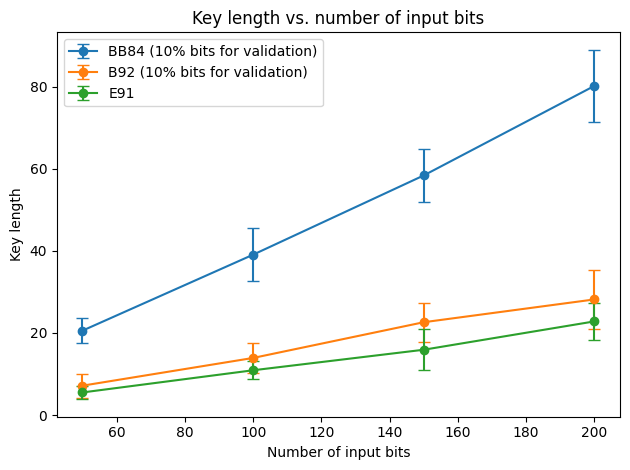

In [8]:
bb84_means = [mean(lens) for lens in bb84_lens]
bb84_stds = [std(lens) for lens in bb84_lens]
b92_means = [mean(lens) for lens in b92_lens]
b92_stds = [std(lens) for lens in b92_lens]
e91_means = [mean(lens) for lens in e91_lens]
e91_stds = [std(lens) for lens in e91_lens]

fig, ax = plt.subplots()
ax.errorbar(bit_vals, bb84_means, yerr=bb84_stds, label=f'BB84 ({PCT_CHK}% bits for validation)', marker='o', capsize=4)
ax.errorbar(bit_vals, b92_means,  yerr=b92_stds,  label=f'B92 ({PCT_CHK}% bits for validation)',  marker='o', capsize=4)
ax.errorbar(bit_vals, e91_means,  yerr=e91_stds,  label='E91',  marker='o', capsize=4)
ax.set_xlabel('Number of input bits')
ax.set_ylabel('Key length')
ax.set_title('Key length vs. number of input bits')
ax.legend()
plt.tight_layout()
plt.show()